In [1]:
import h5py
from lace.cosmo import cosmology
import numpy as np
import matplotlib.pyplot as plt
from cupix.likelihood.theory import Theory

In [2]:
with h5py.File('p3ds.hdf5', 'r') as f:
    k_los = f['k_los'][:]
    k = f['k'][:]
    plin = f['plin'][:]
    mu = f['mu'][:]
    #p3d_lya_me = f['P3d_lya'][:]
    #p3d_hcd_me = f['P3d_hcd'][:]
    #p3d_hcdlya_me = f['P3d_hcdlya'][:]

# Cupix

In [3]:
cosmo = cosmology.Cosmology()
hubble = 0.71
cosmo.CAMBparams.set_cosmology(H0=hubble*100, ombh2=0.046*(hubble**2), omch2=0.27*(hubble**2))

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2500
 max_l_tensor = 600
 max_eta_k = 5000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.0231886
 omch2 = 0.136107
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 71.0
 TCMB = 2.7255
 YHe = 0.24619933960101897
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.9665
 

In [4]:
# redshift and bias / beta from that paper
z = 2.5
bias = -0.18
beta = 1
# close to value used in McQuinn & White, although in there this is kpar smoothing only
kp_Mpc = 0.08 * cosmo.get_dkms_dMpc(z)
print('k_p = {:.3f} 1/Mpc'.format(kp_Mpc))
# HCD model (L_H
b_H = -0.036
beta_H = 0.5
L_H = 7.0  / cosmo.get_h()
print('L_H = {:.3f} Mpc'.format(L_H))
config = dict(bias=bias, beta=beta, q1=0, q2=0, kp_Mpc=kp_Mpc,
              include_hcd=True, b_H=b_H, beta_H=beta_H, L_H=L_H,
              verbose=False)

k_p = 6.136 1/Mpc
L_H = 9.859 Mpc


In [5]:
theory = Theory(z, fid_cosmo=cosmo, config=config)

In [6]:
linP = cosmo.get_linP_Mpc(z, k)

In [7]:
# Cupix
p3d_lya_cupix = []
nonlin = []
for mu_value in mu:
    p3d_lya_cupix.append(theory.get_p3d_lya_Mpc(k=k, mu=mu_value))
    lya_params = theory.lya_model.get_lya_params(cosmo, params={})
    nonlin.append(theory._compute_DNL_Arinyo(k, mu_value, linP, lya_params))
p3d_lya_cupix = np.array(p3d_lya_cupix)
nonlin = np.array(nonlin)

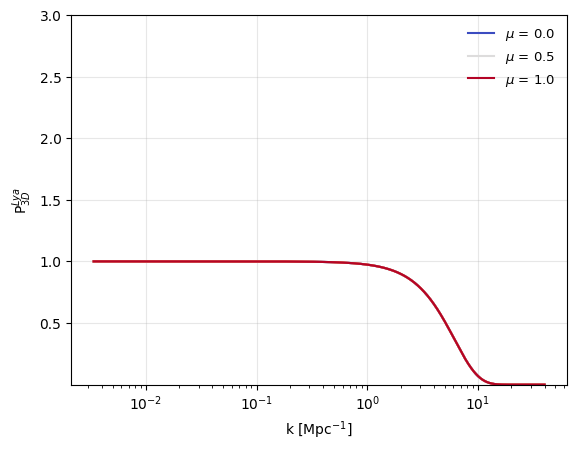

In [8]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, nonlin[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, nonlin[i, :])
plt.xscale('log')
plt.ylim(1e-3, 3)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$');

In [9]:
from scipy.interpolate import RegularGridInterpolator

kperp_max = np.sqrt(k.max()**2-k_los.max()**2)
kperp = np.logspace(np.log10(k_los.min()/10), np.log10(kperp_max), len(k))
m = np.log10(kperp)

KPAR, KPERP = np.meshgrid(k_los, kperp, indexing='ij')
K_TOTAL = np.sqrt(KPAR**2 + KPERP**2)
MU_EFF = KPAR/K_TOTAL
points_target = np.stack([MU_EFF.ravel(), K_TOTAL.ravel()], axis=-1)

In [10]:
interp = RegularGridInterpolator((mu, k), p3d_lya_cupix/nonlin, bounds_error=False, fill_value=0)
p3d_lya_newgrid = interp(points_target).reshape(K_TOTAL.shape)
p1d_lya_cupix = np.trapz(p3d_lya_newgrid*(kperp**2)*np.log(10)/(2*np.pi), m)

In [11]:
interp = RegularGridInterpolator((mu, k), p3d_lya_cupix, bounds_error=False, fill_value=0)
p3d_lya_newgrid = interp(points_target).reshape(K_TOTAL.shape)
p1d_lya_cupix_non = np.trapz(p3d_lya_newgrid*(kperp**2)*np.log(10)/(2*np.pi), m)

# Me

In [12]:
#dkms_sMpc = 76.56311033
dkms_sMpc = cosmo.get_dkms_dMpc(z)
k_d = 0.08*dkms_sMpc  # Mpc^-1
P3d_lya = []
for mu_value in mu:
    k_los_value = k*mu_value
    exp = np.exp(-(k_los_value**2/k_d**2))
    #pf_lya = (bias**2)*((1+beta*mu_value**2)**2)*exp*plin
    pf_lya = (bias**2)*((1+beta*mu_value**2)**2)*exp*linP
    P3d_lya.append(pf_lya)

p3d_lya_me = np.array(P3d_lya)

In [13]:
interp = RegularGridInterpolator((mu, k), p3d_lya_me, bounds_error=False, fill_value=0)
p3d_lya_newgrid = interp(points_target).reshape(K_TOTAL.shape)
p1d_lya_me = np.trapz(p3d_lya_newgrid*(kperp**2)*np.log(10)/(2*np.pi), m)

# Comparisons

## Plin

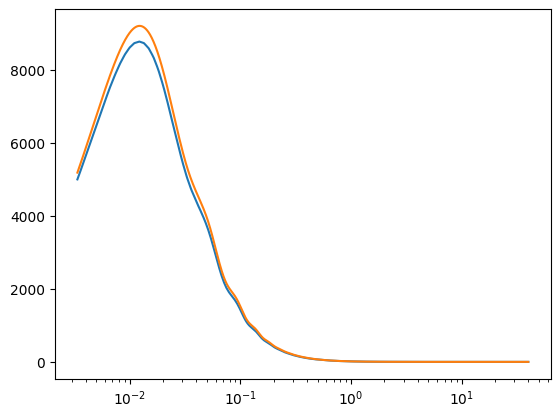

In [14]:
plt.plot(k, plin)
plt.plot(k, linP)
plt.xscale('log')

## P3d

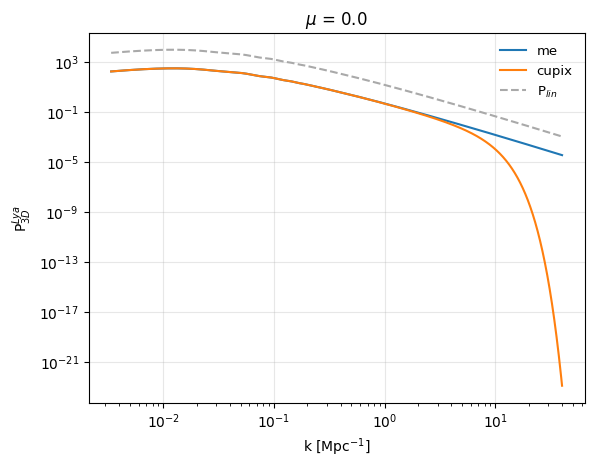

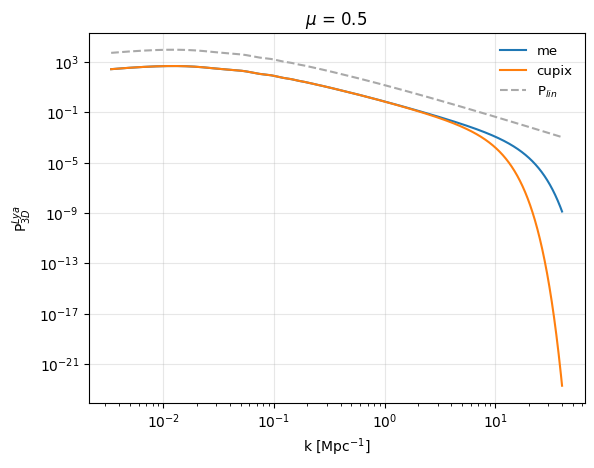

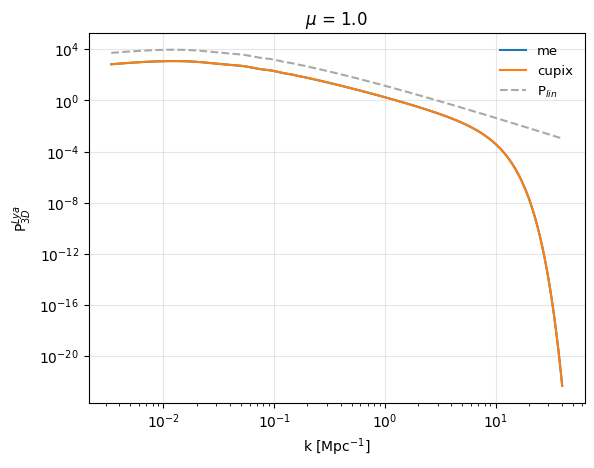

In [15]:
i = 0
plt.plot(k, p3d_lya_me[i, :], label = 'me')
plt.plot(k, p3d_lya_cupix[i, :], label = 'cupix')
plt.plot(k, linP, color='darkgrey', linestyle='--', label=r'P$_{lin}$')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.figure()
i = 5
plt.plot(k, p3d_lya_me[i, :], label = 'me')
plt.plot(k, p3d_lya_cupix[i, :], label = 'cupix')
plt.plot(k, linP, color='darkgrey', linestyle='--', label=r'P$_{lin}$')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

plt.figure()
i = 10
plt.plot(k, p3d_lya_me[i, :], label = 'me')
plt.plot(k, p3d_lya_cupix[i, :], label = 'cupix')
plt.plot(k, linP, color='darkgrey', linestyle='--', label=r'P$_{lin}$')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$')
plt.title(r'$\mu$ = %.1f' %mu[i]);

In [16]:
dif = (p3d_lya_cupix[:1000]/nonlin[:1000])/p3d_lya_me[:1000]  
dif.max()

2.848606878284162e+18

## P1d

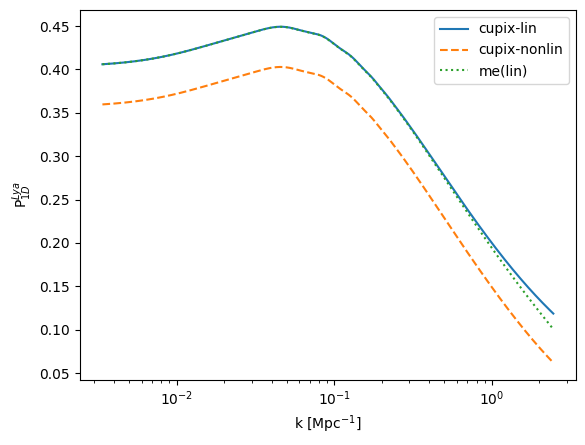

In [17]:
plt.plot(k_los, p1d_lya_cupix, label='cupix-lin')
plt.plot(k_los, p1d_lya_cupix_non, linestyle='--', label='cupix-nonlin')
plt.plot(k_los, p1d_lya_me, linestyle=':', label='me(lin)')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{1D}^{Lya}$');

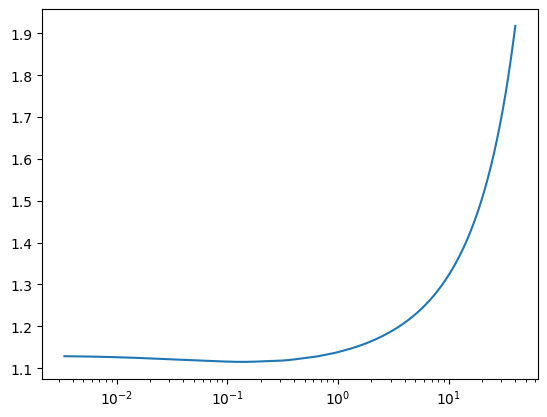

In [18]:
plt.plot(k, p1d_lya_cupix/p1d_lya_cupix_non)
plt.xscale('log')